# SOUND LOCALIZATION
Rahul Vimalkanth

In [146]:
import numpy as np
import matplotlib.pyplot as plt

In [147]:
Nsamp = 200  # Number of time samples
Nmics = 64   # Number of microphones
src = (0, 0)  # Source position (x, y)
obstacle = (-3, 1)  # Obstacle position (x, y)
pitch = 0.1  # Spacing between microphones
dist_per_samp = 0.1  # Sampling distance, affects time between samples
C = 1  # Speed of sound in the medium
SincP = 2.5  # Sharpness factor for sinc pulse

In [148]:
def sensor_positions(Nmics, pitch):
    """Generate positions of microphones spaced along the y-axis."""
    start_position = -pitch * ((Nmics - 1) / 2)
    return [(0, start_position + i * pitch) for i in range(Nmics)]

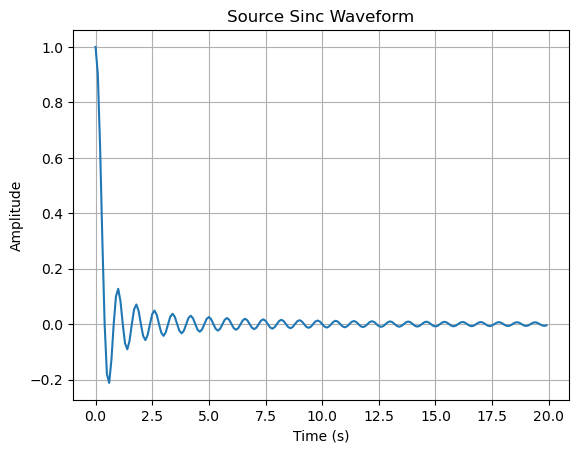

In [149]:
def sinc_waveform(time_points):
    """Generate a sinc pulse waveform based on specified time points."""
    return np.sinc(SincP * time_points)

# Generate and plot source sinc waveform
max_time = Nsamp * dist_per_samp/C
time_points = np.arange(0, max_time, dist_per_samp)
plt.plot(time_points, sinc_waveform(time_points))
plt.title("Source Sinc Waveform")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

In [150]:
def calculate_time_delay(src, obstacle, mic, C):
    """Calculate the time delay from source to obstacle to microphone."""
    def distance(x1, y1, x2, y2):
        return np.sqrt((x1 - x2) ** 2 + (y1 - y2) ** 2)
    
    distance_to_obstacle = distance(src[0], src[1], obstacle[0], obstacle[1])
    distance_to_microphone = distance(obstacle[0], obstacle[1], mic[0], mic[1])
    return (distance_to_obstacle + distance_to_microphone) / C

In [151]:
# Simulate the recordings for each microphone
def data_simulation(Nsamp, mics, src, obstacle, plot=True):
    """Simulate sensor recordings for each microphone given obstacle position."""
    t_dist = dist_per_samp / C
    t = np.linspace(0, Nsamp * t_dist, Nsamp)
    mic_data = []

    for i in range(Nmics):
        t_delay = calculate_time_delay(src, obstacle, mics[i], C)
        y = sinc_waveform(t - t_delay)
        mic_data.append(y)
        if plot:
            plt.plot(t, y + i * 0.05)  # Offset each for visualization

    if plot:
        plt.title("Simulated Sensor Recordings")
        plt.xlabel("Time (s)")
        plt.ylabel("Amplitude (with offset)")
        plt.grid(True)
        plt.show()

    return np.array(mic_data)


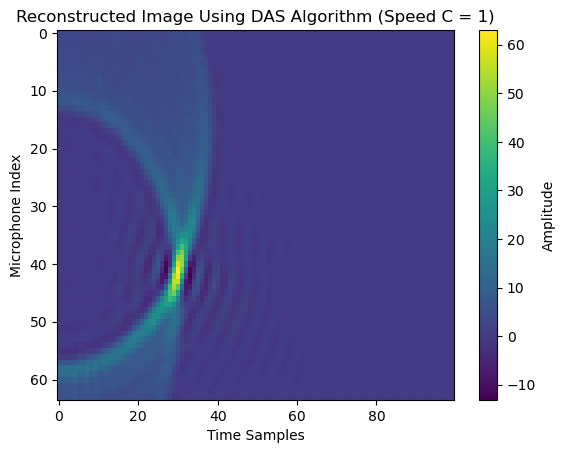

In [152]:
def Delay_and_Sum(Nsamp, Nmics, mic_data, mics):
    """Reconstruct the signal using Delay-and-Sum (DAS) algorithm."""
    reconstructed_image = np.zeros((Nmics, int(Nsamp / 2)))
    t_dist = dist_per_samp / C
    t = np.linspace(0, Nsamp * t_dist, Nsamp)

    for i in range(int(Nsamp / 2)):
        for j in range(Nmics):
            for k in range(Nmics):
                d0 = calculate_time_delay(src, (t[i] * C, mics[j][1]), mics[k], C)
                t0 = d0 / C
                if t0 < Nsamp * t_dist:
                    index = int(t0 / t_dist)
                    if index < mic_data.shape[1]:
                        reconstructed_image[j][i] += mic_data[k][index]

    return reconstructed_image

# Main Execution
mics = sensor_positions(Nmics, pitch)
mic_data = data_simulation(Nsamp, mics, src, obstacle, plot=False)
reconstructed_image = Delay_and_Sum(Nsamp, Nmics, mic_data, mics)

# Display reconstructed image
plt.title(f'Reconstructed Image Using DAS Algorithm (Speed C = {C})')
plt.imshow(reconstructed_image, aspect='auto', interpolation='nearest')
plt.colorbar(label="Amplitude")
plt.xlabel("Time Samples")
plt.ylabel("Microphone Index")
plt.show()

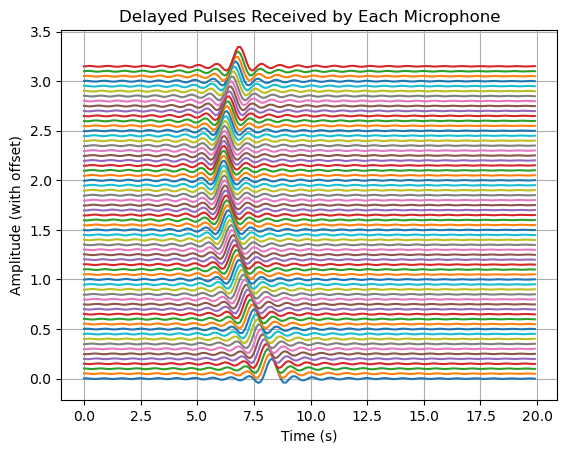

In [153]:
time_points = np.arange(0, max_time, dist_per_samp)
delayed_signals = []
offset = 0

for mic_position in mics:
    delay = calculate_time_delay(src, obstacle, mic_position, C)
    delayed_signal = sinc_waveform(time_points - delay) / 5
    delayed_signals.append(delayed_signal)
    plt.plot(time_points, delayed_signal + offset)
    offset += 0.05  # Increase offset for visualization

plt.title("Delayed Pulses Received by Each Microphone")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude (with offset)")
plt.grid(True)
plt.show()


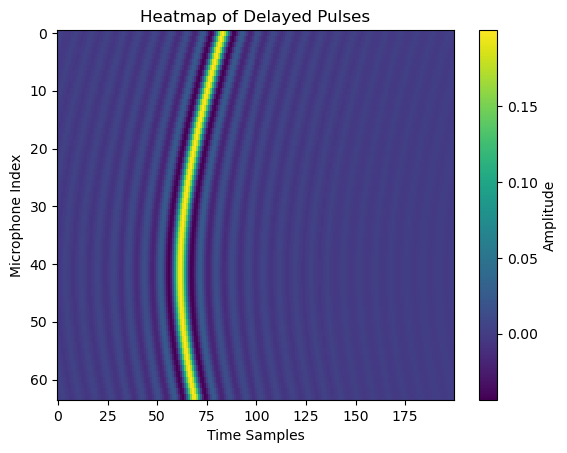

In [154]:
# Generate and plot delayed signals received by each microphone
delayed_signals = []
for mic_position in mics:
    delay = calculate_time_delay(src, obstacle, mic_position, C)
    delayed_signal = sinc_waveform(time_points - delay) / 5  # Scale down for visualization
    delayed_signals.append(delayed_signal)

# Display heatmap of delayed pulses across microphones
signal_array = np.vstack(delayed_signals)
plt.imshow(signal_array, aspect='auto', interpolation='nearest')
plt.title("Heatmap of Delayed Pulses")
plt.colorbar(label="Amplitude")
plt.xlabel("Time Samples")
plt.ylabel("Microphone Index")
plt.show()


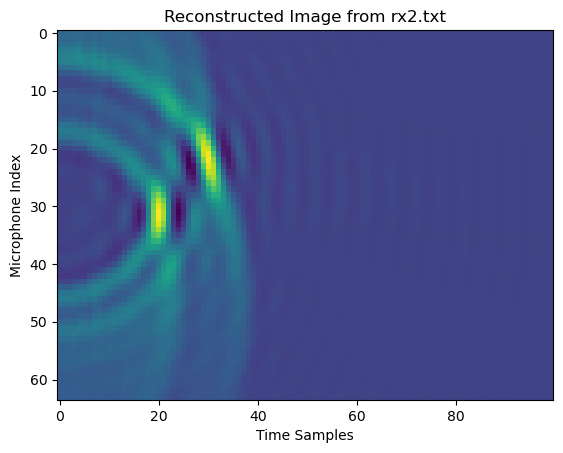

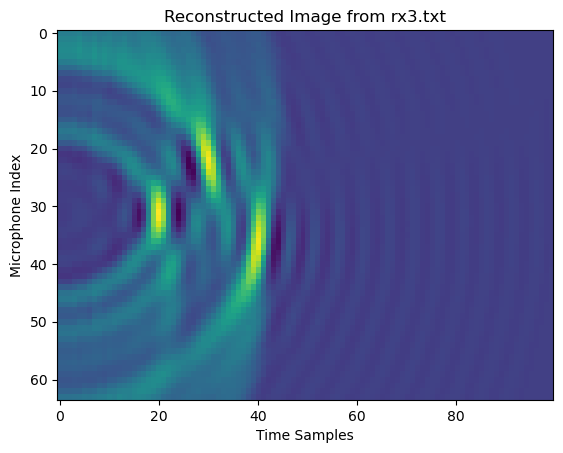

In [155]:
def load_and_reconstruct(file_name):
    """Load microphone data from file and reconstruct image using delay-and-sum algorithm."""
    loaded_data = np.loadtxt(file_name)
    reconstructed_image = Delay_and_Sum(Nsamp, Nmics, loaded_data, mics)
    plt.imshow(reconstructed_image, aspect='auto', interpolation='nearest')
    plt.title(f"Reconstructed Image from {file_name}")
    plt.xlabel("Time Samples")
    plt.ylabel("Microphone Index")
    plt.show()

# Reconstruct images from data in files
load_and_reconstruct("rx2.txt")
load_and_reconstruct("rx3.txt")


# Answers for the Questions

### 1) The plots below show two example sinc pulses. How will you generate pulses that look like this? Which parameter should be changed? What effect do you think this will have on the final image?

To generate pulses similar to the ones shown in the plots, use the `wrsc(t)` function based on the sinc function:

- Set C: Set the value of **C** to 2.
  
- Adjust SincP: The key parameter to modify is **SincP**, which controls the width of the sinc pulse:
  - For a wider pulse (first plot), set **SincP** to `1.0`.
  - For a narrower, sharper pulse (second plot), set **SincP** to `5.0`.

- Other Parameters: You can also adjust **Nsamp** and **dist_per_samp**, but **SincP** is the primary determinant of pulse shape.

#### Effects on Final Image:
- Increasing SincP (compressing the pulse) sharpens the image, resulting in higher resolution and finer details.
- Decreasing SincP (stretching the pulse) produces a smoother image with lower resolution.

#### Frequency Considerations:
- Higher frequency increases resolution by causing a quicker drop-off in the sinc function.
- Lower frequency results in a gentler decay, yielding a smoother image with less detail.

By adjusting **SincP** and frequency parameters, you can effectively control the resolution and clarity of the final reconstructed image.

---

### 2) Does it make sense to reconstruct up to $ N_{samp} $? What value is more reasonable as an upper limit for the x-axis here?

No, it does not make sense to reconstruct up to $ N_{samp} $.
A more reasonable upper limit for the x-axis is given by 

$$
\frac{N_{samp} \times \text{dist\_per\_samp}}{C}
$$

This value represents the maximum distance that can be reliably reconstructed based on the time samples. The reasoning behind this is that the reconstruction is fundamentally tied to the time it takes for sound to travel from the source to the obstacle and back. Thus, using this formula ensures that we account for the time delay associated with sound propagation, which is crucial for accurate image reconstruction.

---

### 3) The (x, y) coordinates corresponding to the maximum amplitude (yellow colour) is approximately (30, 22). Explain why this is the correct expected position for the given obstacle.

The coordinates (30, 22) are indeed the expected position of the obstacle based on how the data was structured. 

- The x-coordinate of 30 corresponds to a distance of $ 30 \times 0.1 = 3 $ units from the source along the horizontal axis. 

- The y-coordinate of 22 indicates that it corresponds to the 22nd microphone from the bottom in a grid of 64 microphones. Since each microphone is spaced by a distance of 0.1 units, this means that this microphone is at a vertical position of 

$$
-1 = (32 - 22) \times 0.1
$$

Thus, in real-world coordinates, (30, 22) translates to (3, -1), which aligns perfectly with our expectations for the obstacle's position.

---

### 4) What is the maximum obstacle x- and y- coordinate that you can use and still have an image reconstructed?

The maximum x-coordinate that can be used for reconstruction is 

$$
\frac{N_{samp} \times \text{dist\_per\_samp}}{C}
$$

This ensures that we only consider distances within a range that can be detected based on sound travel time.

For the y-coordinate, as long as it falls within the range defined by $ N_{mics} $, you will still get a decent reconstructed image. Practically, this means that you can use y-coordinates corresponding to any of the microphones in your array.

---

### 5) What happens if $ C $ is different - if $ C $ is decreased it looks like the image becomes sharper. Can you explain why intuitively?

When $ C $, which represents the speed of sound, is decreased, it results in a longer time taken for sound waves to travel from the source to obstacles and back. This leads to:

- Increased Time Samples: A lower speed means that sound waves take longer to reach different microphones, which allows for more precise timing and better differentiation between signals received at different times.

- Sharper Images: With more time samples available due to lower speed, beamforming algorithms can better focus and resolve details in the sound wave patterns. This results in sharper images because there are fewer ambiguities in determining where obstacles are located.

---

### 6) What happens if $ N_{mics} $ is increased or decreased? Do the experiments with $ N_{mics} = [8, 32, 64] $ and $ N_{samp} = [50, 100, 200] $ (all combinations). Attach the resulting images.

Increasing or decreasing $ N_{mics} $ affects how well you can estimate the y-coordinate of an obstacle:

- Increased $ N_{mics} $: More microphones provide better spatial resolution and increase your ability to detect obstacles at various heights. This leads to clearer and more accurate reconstructions of images.

- Decreased $ N_{mics} $: Fewer microphones reduce vertical resolution and may lead to ambiguity in determining obstacle locations. The resulting images may become less distinct and harder to interpret.

The experiments with various combinations of $ N_{mics} $ and $ N_{samp} $ will yield different levels of clarity in reconstructed images. Generally:

- With more microphones: The resulting images will show clearer distinctions between obstacles.
  
- With fewer microphones: The images may appear more blurred or may fail to capture certain obstacles entirely.

These changes highlight how critical microphone density and sampling rate are in acoustic imaging applications.
